In [18]:
#  SUPERDENSE CODING  —  Sending 2 classical bits over 1 quantum channel
# -----------------------------------------------------------------------------------------------
"""
Normally, to send 2 classical bits you need 2 classical bits. Superdense coding exploits quantum 
entanglement to beat that limit:
Alice pre-shares ONE entangled qubit with Bob, then later sends just ONE qubit to convey 
a full 2-bit message. The "magic" is already there in the entanglement — Alice just has to choose 
which of four Pauli rotations to apply before shipping her qubit.

Alice — wants to send a 2-bit message to Bob
Bob   — receives Alice's qubit and decodes the message
EPR   — the entangled Bell pair they share in advance

What are we gonna do at a glance!
(shared beforehand)      (Alice acts)         (Bob acts)
Prepare |phi+⟩  -------->  encode msg  ------->  decode  --->  measure
-------------------------------------------------------------------------------------------------
"""

!pip install qiskit qiskit-aer   
#(run once in your environment)
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

Defaulting to user installation because normal site-packages is not writeable


In [19]:
#  CONFIGURATION (only thing to change for different runs)
# ---------------------------------------------------------------------------------------------
MESSAGE = "10"    # Alice's secret 2-bit message: one of "00", "01", "10", "11"
SHOTS   = 1024    # How many times we re-run the circuit

VALID_MESSAGES = {"00", "01", "10", "11"}
if MESSAGE not in VALID_MESSAGES:
    raise ValueError(f"MESSAGE must be one of {VALID_MESSAGES}. Got: '{MESSAGE}'")

#  ENCODING TABLE  — Alice's 4 possible actions on her qubit
# ---------------------------------------------------------------------------------------------
"""
The four Bell states are orthogonal, so Bob can always tell them apart. Each Pauli gate steers 
the shared Bell state into a different one:

Message │ Gate │ Transforms |phi+⟩ to ...  │ Intuition
--------|------|---------------------------|------------------------------
 "00"   │  I   │   |Φ+⟩ = (|00⟩+|11⟩)/√2    │ Do nothing — state unchanged
 "01"   │  X   │   |Ψ+⟩ = (|01⟩+|10⟩)/√2    │ Bit-flip Alice's qubit
 "10"   │  Z   │   |Φ-⟩ = (|00⟩-|11⟩)/√2    │ Phase-flip Alice's qubit
 "11"   │  Y   │   |Ψ-⟩ = (|01⟩-|10⟩)/√2    │ Both flips (Y = iXZ)

Note: Y introduces a global phase of i, which is physically undetectable.
Bob's measurement outcome is identical regardless of that phase.
"""

ENCODING_TABLE = {
    "00": ("I", "Identity — leave the Bell state as |phi+⟩"),
    "01": ("X", "Bit-flip  — steer Bell state to |psi+⟩"),
    "10": ("Z", "Phase-flip — steer Bell state to |phi-⟩"),
    "11": ("Y", "Both flips — steer Bell state to |psi-⟩ (global phase ignored)"),
}

def apply_alice_encoding(qc, qubit, msg):
    """
    Apply Alice's single-qubit encoding gate.
    This is the ONLY operation Alice performs after the pair is shared. She never touches Bob's 
    qubit — that's what makes the protocol remarkable.
    """
    if msg == "00":
        qc.id(qubit)   # Explicit identity keeps the circuit diagram readable
    elif msg == "01":
        qc.x(qubit)    # Pauli-X: |0⟩->|1⟩  (quantum NOT gate)
    elif msg == "10":
        qc.z(qubit)    # Pauli-Z: |0⟩->|0⟩, |1⟩->−|1⟩  (phase flip)
    elif msg == "11":
        qc.y(qubit)    # Pauli-Y = iXZ: bit-flip + phase-flip combined


#  QUBIT LAYOUT
# ---------------------------------------------------------------------------------------------
"""
q[1] <- Alice's qubit  (she acts on this one)
q[0] <- Bob's qubit    (he holds this quietly until decoding)

(Why this order?  
Qiskit reads measurement results as q[1]q[0] (big-endian),so the final bitstring will naturally 
read as the intended 2-bit message.)
"""
qr = QuantumRegister(2, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr, name="SuperdenseCoding")

In [20]:
# ENTANGLEMENT GENERATION  (happens before Alice knows her message)
# ------------------------------------------------------------------------------
"""
We build the Bell state |phi+⟩ = (|00⟩ + |11⟩) / √2
How:
H  on q[1] -> superposition: (|0⟩ + |1⟩) / √2  (q[1] is now "half-0, half-1")
CX on q[1]->q[0] -> entangles: if q[1]=|1⟩, flip q[0]
After this, neither qubit has a definite value on its own, they are correlated: 
measuring one instantly determines the other, no matter how far apart Alice and Bob are 
(Einstein called it "spooky action").
"""

qc.h(qr[1])               # Hadamard: puts Alice's qubit in superposition
qc.cx(qr[1], qr[0])       # CNOT: entangles Alice's qubit with Bob's

qc.barrier(label="EPR pair ready")

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [21]:
# ALICE ENCODES HER MESSAGE  (she acts on her qubit only)
# ------------------------------------------------------------------------------------------------
"""
Alice applies one of {I, X, Z, Y} based on the 2-bit message she wants to send.  This single-qubit 
gate secretly "steers" the shared Bell state into one of four orthogonal states that Bob can later 
distinguish.
Alice sends her qubit to Bob through a quantum channel.
She does NOT send the classical message — that's the whole point.
"""

apply_alice_encoding(qc, qr[1], MESSAGE)

qc.barrier(label="Alice sends qubit")   # Alice's qubit is now in transit

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [22]:
# BOB DECODES  (Bell-basis measurement)
# -------------------------------------------------------------------------------------------------
"""
Bob performs the inverse Bell circuit to "undo" the entanglement and extract the two classical bits 
hiding in the joint quantum state:
CX (Alice's qubit controls Bob's) -> unentangles the pair
H  on Alice's qubit               -> rotates back from superposition
After these two gates the qubits are in a plain computational-basis state (no superposition, 
no entanglement) so measurement gives a deterministic result.
"""

qc.cx(qr[1], qr[0])   # Un-entangle: CNOT with Alice's qubit as control
qc.h(qr[1])           # Un-superpose: Hadamard maps |+⟩->|0⟩ and |−⟩->|1⟩

qc.barrier(label="Bob decodes")   # decoding complete

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [23]:
# MEASUREMENT
# --------------------------------------------------------------------------------- 
"""
Both qubits are now in a definite classical state. We measure them into the classical register.
The 2-bit result should match Alice's original message.
"""

qc.measure(qr, cr)

In [24]:
# CIRCUIT OVERVIEW
# ---------------------------------------------------------

gate, description = ENCODING_TABLE[MESSAGE]
print("  SUPERDENSE CODING — Qiskit Aer Simulation")
print("-" * 62)
print(f"\n  Alice's secret message : {MESSAGE}")
print(f"  Encoding gate used     : {gate}  ({description})")
print(f"  Simulation shots       : {SHOTS}")
print(f"  Circuit depth          : {qc.depth()}")
print(f"  Gate counts            : {dict(qc.count_ops())}")

print("\n" + "-" * 62)
print("  ENCODING TABLE  (all four possible messages)")
print("-" * 62)
for msg, (g, desc) in ENCODING_TABLE.items():
    marker = "<< THIS RUN" if msg == MESSAGE else ""
    print(f"  {msg}  │  {g}  │  {desc}  {marker}")

print("\n" + "-" * 62)
print("  QUANTUM CIRCUIT (text diagram)")
print("-" * 62)
print(qc.draw(output="text"))

  SUPERDENSE CODING — Qiskit Aer Simulation
--------------------------------------------------------------

  Alice's secret message : 10
  Encoding gate used     : Z  (Phase-flip — steer Bell state to |phi-⟩)
  Simulation shots       : 1024
  Circuit depth          : 6
  Gate counts            : {'barrier': 3, 'h': 2, 'cx': 2, 'measure': 2, 'z': 1}

--------------------------------------------------------------
  ENCODING TABLE  (all four possible messages)
--------------------------------------------------------------
  00  │  I  │  Identity — leave the Bell state as |phi+⟩  
  01  │  X  │  Bit-flip  — steer Bell state to |psi+⟩  
  10  │  Z  │  Phase-flip — steer Bell state to |phi-⟩  << THIS RUN
  11  │  Y  │  Both flips — steer Bell state to |psi-⟩ (global phase ignored)  

--------------------------------------------------------------
  QUANTUM CIRCUIT (text diagram)
--------------------------------------------------------------
          ┌───┐ EPR pair ready       Alice sends qu

In [25]:
#  SIMULATION — run on Aer (noiseless statevector-based simulator)
# ------------------------------------------------------------------------

backend = AerSimulator()
transpiled_circuit = transpile(qc, backend)

job    = backend.run(transpiled_circuit, shots=SHOTS)
result = job.result()
counts = result.get_counts(transpiled_circuit)

# Ensure all four bitstrings appear in the output (zero-fill missing ones)
ordered_keys   = ["00", "01", "10", "11"]
ordered_counts = {k: counts.get(k, 0) for k in ordered_keys}

# The decoded message is whichever bitstring was measured most often
received_message    = max(ordered_counts, key=ordered_counts.get)
success_probability = ordered_counts[MESSAGE] / SHOTS

In [26]:
# MEASUREMENT RESULTS
# ----------------------------------------------------------------------------

print("\n" + "-" * 62)
print("  MEASUREMENT RESULTS")
print("-" * 62)
for bitstring, count in ordered_counts.items():
    prob    = count / SHOTS
    bar     = "|||" * int(prob * 30)   # progress bar
    pointer = "<< decoded" if bitstring == MESSAGE else ""
    print(f"  {bitstring}  │  {bar:<30}  {count:4d}  ({prob:.1%})  {pointer}")

print("\n" + "-" * 62)
print("  VERDICT")
print("-" * 62)
print(f"  Alice sent     : {MESSAGE}")
print(f"  Bob received   : {received_message}")
print(f"  Fidelity       : {100 * success_probability:.1f}%")

if success_probability == 1.0:
    print("\n    Perfect transmission — Bob recovered the message with")
    print("      100% probability.  No noise, no errors, textbook result.")
else:
    print("\n    Non-ideal result — check circuit or noise model.")


--------------------------------------------------------------
  MEASUREMENT RESULTS
--------------------------------------------------------------
  00  │                                     0  (0.0%)  
  01  │                                     0  (0.0%)  
  10  │  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||  1024  (100.0%)  << decoded
  11  │                                     0  (0.0%)  

--------------------------------------------------------------
  VERDICT
--------------------------------------------------------------
  Alice sent     : 10
  Bob received   : 10
  Fidelity       : 100.0%

    Perfect transmission — Bob recovered the message with
      100% probability.  No noise, no errors, textbook result.


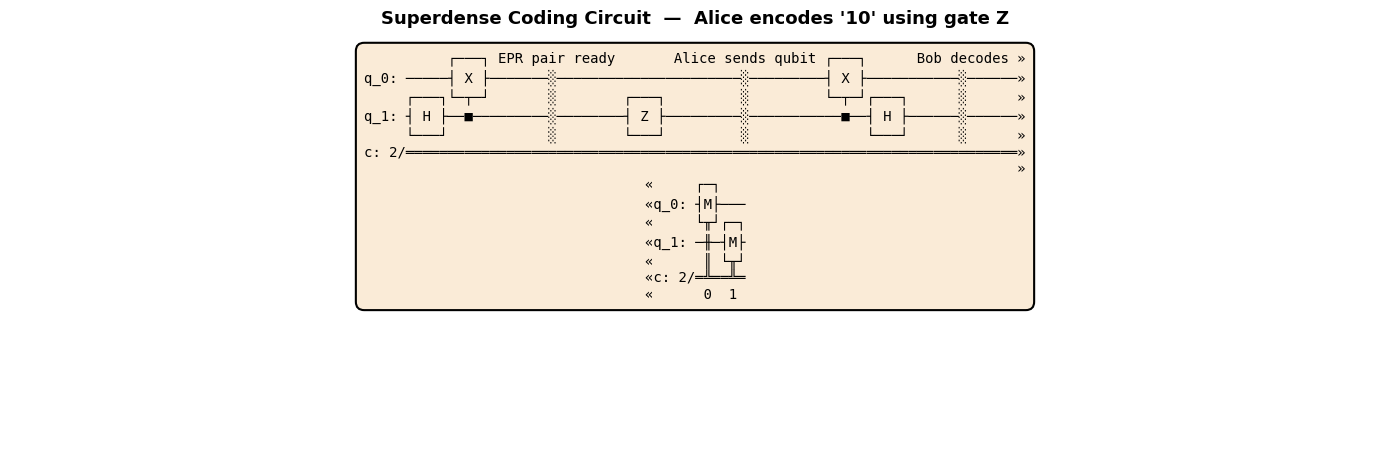

In [27]:
#  PLOT 1 — CIRCUIT DIAGRAM  
# ---------------------------------------------------------------------------------------------
"""
We deliberately avoid qc.draw(output='mpl') because it requires pylatexenc and can silently fail. The
text-in-figure approach is portable and produces an equivalent Matplotlib artifact.
"""

text_diagram = str(qc.draw(output="text"))

fig, ax = plt.subplots(figsize=(14, 4.8))
fig.patch.set_facecolor("white")
ax.axis("off")

ax.text(
    0.5, 0.98, text_diagram,
    transform=ax.transAxes,
    va="top", ha="center",
    family="monospace",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="Antiquewhite", edgecolor="Black", linewidth=1.5)
)

ax.set_title(
    f"Superdense Coding Circuit  —  Alice encodes '{MESSAGE}' using gate {gate}",
    fontsize=13, pad=14, fontweight="bold"
)

plt.tight_layout()
plt.savefig("superdense_circuit.png", dpi=150, bbox_inches="tight")
plt.show()

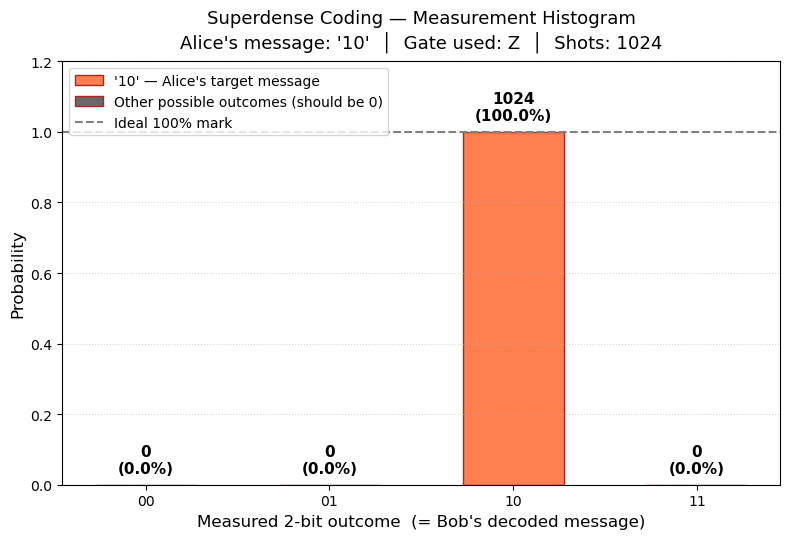

In [29]:
#  PLOT 2 — MEASUREMENT HISTOGRAM
# ----------------------------------------------------------------------------------------------
"""
Each bar shows the fraction of shots that produced that 2-bit outcome. In a noiseless simulation 
the target message bar should reach exactly 1.0.
"""

bitstrings = ["00", "01", "10", "11"]
probs      = [ordered_counts[b] / SHOTS for b in bitstrings]
bar_values = [ordered_counts[b] for b in bitstrings]

# Colour scheme: target message → coral red,  others → steel blue
colors = ["Coral" if b == MESSAGE else "dimgray" for b in bitstrings]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(bitstrings, probs, color=colors, edgecolor="firebrick", width=0.55)

# Annotate each bar with count and percentage
for bar, count, prob in zip(bars, bar_values, probs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        prob + 0.025,
        f"{count}\n({prob:.1%})",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

# Styling
ax.set_ylim(0, 1.20)
ax.set_xlabel("Measured 2-bit outcome  (= Bob's decoded message)", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title(
    f"Superdense Coding — Measurement Histogram\n"
    f"Alice's message: '{MESSAGE}'  │  Gate used: {gate}  │  Shots: {SHOTS}",
    fontsize=13, pad=10
)

# Reference line at 100 % probability
ax.axhline(1.0, color="grey", linestyle="--", linewidth=1.5, label="100 % probability")

# Custom legend explaining colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="coral", edgecolor="firebrick", label=f"'{MESSAGE}' — Alice's target message"),
    Patch(facecolor="dimgray", edgecolor="firebrick", label="Other possible outcomes (should be 0)"),
    plt.Line2D([0], [0], color="grey", linestyle="--", linewidth=1.5, label="Ideal 100% mark"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("superdense_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
#  FINAL SUMMARY
# ---------------------------------------------------------------------------------------------------

print("\n" + "-" * 62)
print("  Summary:  ")
print(f"""
  1. ENTANGLEMENT SETUP
     Alice and Bob each took one qubit from an entangled Bell pair |phi+⟩ = (|00⟩ + |11⟩)/√2.  
     Neither qubit had a definite value on its own — they were perfectly correlated non-locally.

  2. ALICE'S ENCODING
     Alice wanted Bob to receive the message "{MESSAGE}". She applied the Pauli-{gate} gate to her 
     qubit. That secretly "steered" the shared state into a unique Bell state that encodes 
     "{MESSAGE}" and only "{MESSAGE}".

  3. ALICE SENDS ONE QUBIT
     Alice transmitted just her single qubit to Bob. Classically this carries at most 1 bit of 
     information, yet it secretly carries 2 bits, thats for entanglement.

  4. BOB'S DECODING
     Bob ran the inverse Bell circuit (CX then H) on the two qubits. This "unzipped" the entanglement 
     and collapsed the state into a plain 2-bit string.

  5. MEASUREMENT
     After {SHOTS} shots, Bob measured "{received_message}" with 
     {100*success_probability:.1f}% probability — matching Alice's original message "{MESSAGE}" 
     perfectly.

  Note: The two classical bits were teleported via one quantum bit because entanglement pre-loaded 
  the channel with one extra bit of capacity (quantum mutual information).
""")
print("-" * 62)


--------------------------------------------------------------
  Summary:  

  1. ENTANGLEMENT SETUP
     Alice and Bob each took one qubit from an entangled Bell pair |phi+⟩ = (|00⟩ + |11⟩)/√2.  
     Neither qubit had a definite value on its own — they were perfectly correlated non-locally.

  2. ALICE'S ENCODING
     Alice wanted Bob to receive the message "10". She applied the Pauli-Z gate to her 
     qubit. That secretly "steered" the shared state into a unique Bell state that encodes 
     "10" and only "10".

  3. ALICE SENDS ONE QUBIT
     Alice transmitted just her single qubit to Bob. Classically this carries at most 1 bit of 
     information, yet it secretly carries 2 bits, thats for entanglement.

  4. BOB'S DECODING
     Bob ran the inverse Bell circuit (CX then H) on the two qubits. This "unzipped" the entanglement 
     and collapsed the state into a plain 2-bit string.

  5. MEASUREMENT
     After 1024 shots, Bob measured "10" with 
     100.0% probability — matching